In [1]:
# Setup
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# GPU memory config
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

print(f"TensorFlow version: {tf.__version__}")
print("GPU Available:", tf.config.list_physical_devices('GPU'))

np.random.seed(42)
tf.random.set_seed(42)

# Constants
LATENT_DIM = 64
KL_WEIGHT = 8.0
BATCH_SIZE = 512
LEARNING_RATE = 0.0003
CLIPNORM = 2.0

BASE_FILTERS = 64
NUM_LAYERS = 4
BOTTLENECK_DIM = 2
# BOTTLENECK_DIM ^ (NUM_LAYERS + 1) MUST = IMAGE_SIZE (e.g. 2^5 = 32)
IMAGE_SIZE_X = 32
IMAGE_SIZE_Y = 32
CHANNELS = 3

2026-04-11 17:21:06.165331: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-11 17:21:06.772012: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-11 17:21:09.227544: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Sampling Layer
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = keras.random.normal(shape=keras.ops.shape(z_mean), dtype=z_mean.dtype)
        return z_mean + keras.ops.exp(0.5 * z_log_var) * epsilon

# Encoder
def build_encoder(latent_dim=LATENT_DIM):
    inputs = keras.Input(shape=(IMAGE_SIZE_X, IMAGE_SIZE_Y, CHANNELS))
   
    x = inputs
    for i in range(NUM_LAYERS):
         filters = BASE_FILTERS * (2 ** i)
         x = layers.Conv2D(filters, 3, strides=2, padding='same', activation='relu')(x)
         x = layers.BatchNormalization()(x)
    
    x = layers.Flatten()(x)
    x = layers.Dropout(0.2)(x)
    
    z_mean    = layers.Dense(latent_dim, name='z_mean')(x)
    z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)
    z         = Sampling()([z_mean, z_log_var])
    
    return keras.Model(inputs, [z_mean, z_log_var, z], name='encoder')

# Decoder
def build_decoder(latent_dim=LATENT_DIM):
    inputs = keras.Input(shape=(latent_dim,))

    final_filters = BASE_FILTERS * (2 ** (NUM_LAYERS - 1))
    
    x = layers.Dense(BOTTLENECK_DIM * BOTTLENECK_DIM * final_filters, activation='relu')(inputs)
    x = layers.Reshape((BOTTLENECK_DIM, BOTTLENECK_DIM, final_filters))(x)

    for i in range(NUM_LAYERS - 1, -1, -1):
        filters = BASE_FILTERS * (2 ** i)
        x = layers.Conv2DTranspose(filters, 3, strides=2, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
    
    outputs = layers.Conv2D(CHANNELS, 3, padding='same', activation='tanh', dtype='float32')(x)
    
    return keras.Model(inputs, outputs, name='decoder')

# VAE
class VAE(keras.Model):
    def __init__(self, encoder, decoder, kl_weight, **kwargs):
        super().__init__(**kwargs)
        self.encoder   = encoder
        self.decoder   = decoder
        self.kl_weight = kl_weight

    def call(self, x):
        z_mean, z_log_var, z = self.encoder(x)
        return self.decoder(z)

    def _compute_losses(self, x, reconstruction, z_mean, z_log_var):
        image_size = tf.cast(tf.reduce_prod(tf.shape(x)[1:3]), tf.float32)
        recon_loss = tf.reduce_mean(
            keras.losses.mse(x, reconstruction)
        ) * image_size
        kl_loss = -0.5 * tf.reduce_mean(
            z_log_var - tf.square(z_mean) - tf.exp(z_log_var) + 1
        )
        total_loss = recon_loss + self.kl_weight * kl_loss
        return {"loss": total_loss, "recon_loss": recon_loss, "kl_loss": kl_loss}

    def train_step(self, data):
        x, _ = data
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(x, training=True)
            reconstruction       = self.decoder(z, training=True)
            losses               = self._compute_losses(x, reconstruction, z_mean, z_log_var)
        grads = tape.gradient(losses["loss"], self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return losses

    def test_step(self, data):
        x, _ = data
        z_mean, z_log_var, z = self.encoder(x, training=False)
        reconstruction       = self.decoder(z, training=False)
        return self._compute_losses(x, reconstruction, z_mean, z_log_var)

encoder = build_encoder(latent_dim=LATENT_DIM)
decoder = build_decoder(latent_dim=LATENT_DIM)
vae     = VAE(encoder, decoder, kl_weight=KL_WEIGHT, name='vae')
vae.compile(optimizer=keras.optimizers.Adam(
    learning_rate=LEARNING_RATE,
    clipnorm=CLIPNORM
))
print("VAE built successfully")

I0000 00:00:1775924470.916587   36499 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


VAE built successfully


In [3]:
# Load CIFAR-10
(x_train, _), (x_test, _) = keras.datasets.cifar10.load_data()

x_train = (x_train.astype('float32') / 127.5) - 1.0
x_test  = (x_test.astype('float32')  / 127.5) - 1.0

print(f"Training data: {x_train.shape}")
print(f"Test data:     {x_test.shape}")

# tf.data pipeline
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, x_train))
train_dataset = train_dataset.shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset   = tf.data.Dataset.from_tensor_slices((x_test, x_test))
val_dataset   = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Callbacks
checkpoint = keras.callbacks.ModelCheckpoint(
    'best_vae.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)
lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.75, patience=5, min_lr=1e-6
)

history = vae.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=[early_stopping, lr_scheduler]
)

/home/username/tf-env/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training data: (50000, 32, 32, 3)
Test data:     (10000, 32, 32, 3)
Epoch 1/50


2026-04-11 17:21:23.500320: I external/local_xla/xla/service/service.cc:163] XLA service 0x713e44022390 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-11 17:21:23.500389: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-04-11 17:21:23.682889: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-11 17:21:24.905856: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-04-11 17:21:25.983745: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4094', 572 bytes spill stores, 572 bytes spill loads

2026-04-11 17:21:26.334738: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.c

97/98 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - kl_loss: 14.4902 - loss: 258.9903 - recon_loss: 143.0690

2026-04-11 17:21:55.758300: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4094', 880 bytes spill stores, 752 bytes spill loads

2026-04-11 17:21:56.426731: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 10408 bytes spill stores, 10108 bytes spill loads



98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - kl_loss: 14.3610 - loss: 257.3719 - recon_loss: 142.4840

2026-04-11 17:22:13.272189: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 11016 bytes spill stores, 11128 bytes spill loads

2026-04-11 17:22:17.793652: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 10408 bytes spill stores, 10108 bytes spill loads



98/98 ━━━━━━━━━━━━━━━━━━━━ 64s 368ms/step - kl_loss: 1.8309 - loss: 100.3798 - recon_loss: 85.7325 - val_kl_loss: 0.2437 - val_loss: 260.1754 - val_recon_loss: 258.2257 - learning_rate: 3.0000e-04
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - kl_loss: 1.8607 - loss: 86.9200 - recon_loss: 72.0347 - val_kl_loss: 0.5847 - val_loss: 231.8892 - val_recon_loss: 227.2113 - learning_rate: 3.0000e-04
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - kl_loss: 1.8565 - loss: 80.5228 - recon_loss: 65.6709 - val_kl_loss: 0.8429 - val_loss: 168.8922 - val_recon_loss: 162.1493 - learning_rate: 3.0000e-04
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - kl_loss: 1.8691 - loss: 72.4777 - recon_loss: 57.5252 - val_kl_loss: 1.1219 - val_loss: 109.2394 - val_recon_loss: 100.2641 - learning_rate: 3.0000e-04
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - kl_loss: 1.8091 - loss: 69.6734 - recon_loss: 55.2007 - val_kl_loss: 1.4601 - val_loss: 71.2443 - val_recon_loss: 59.5637 - learning_ra

/tmp/ipykernel_36499/1175761121.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


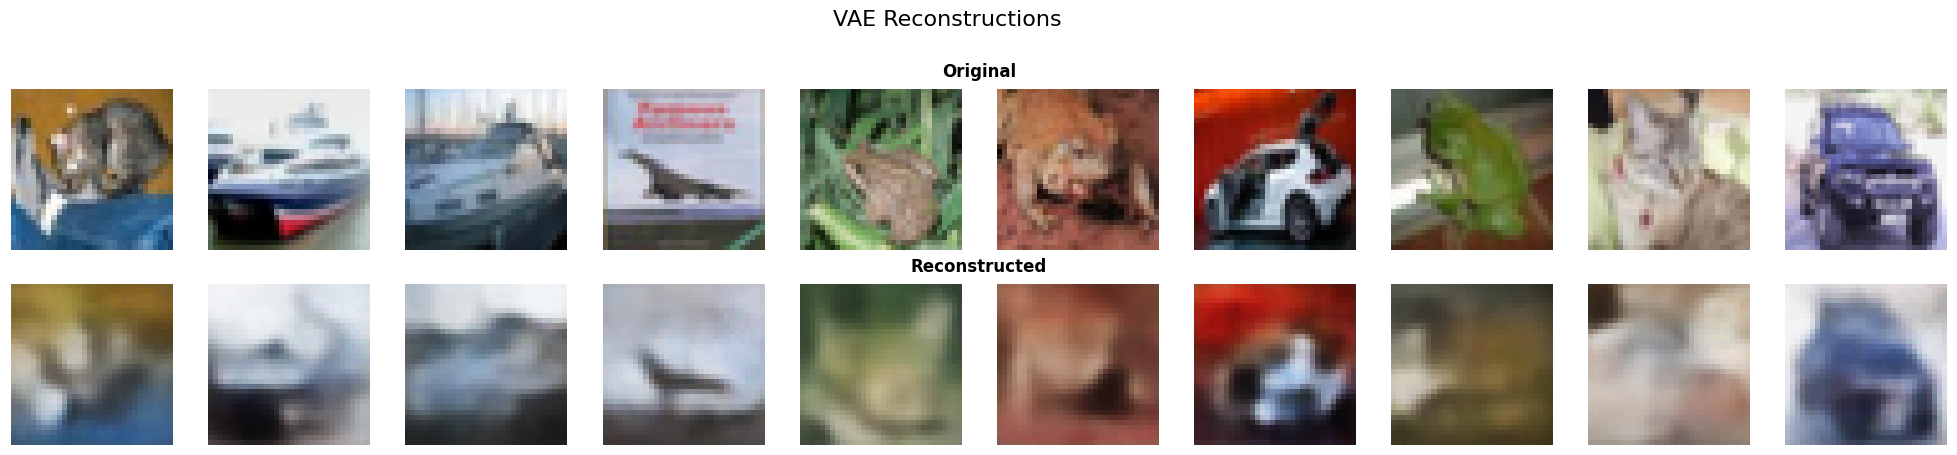

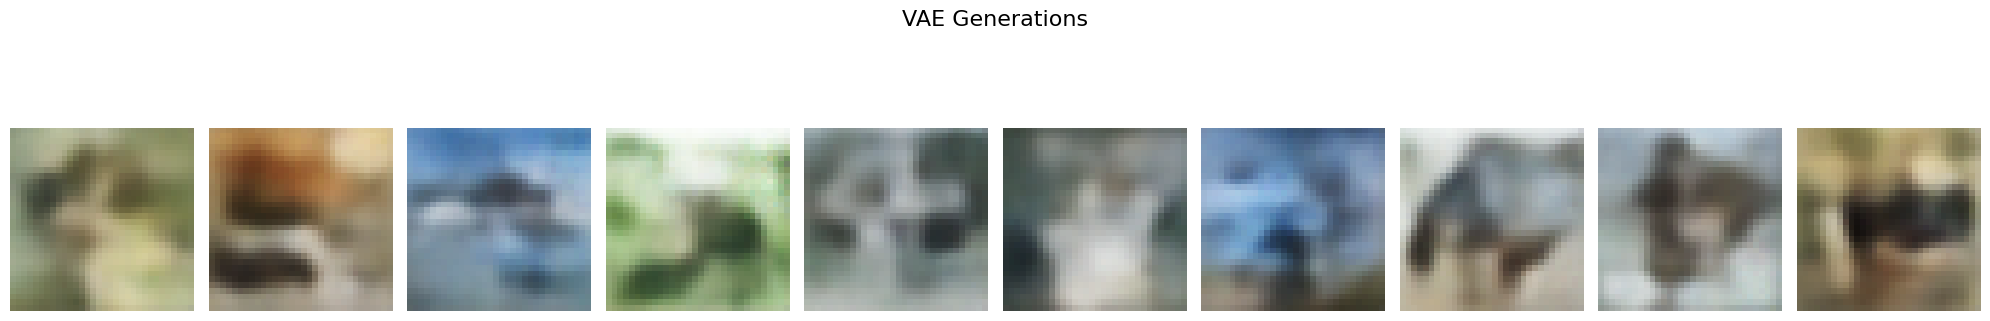

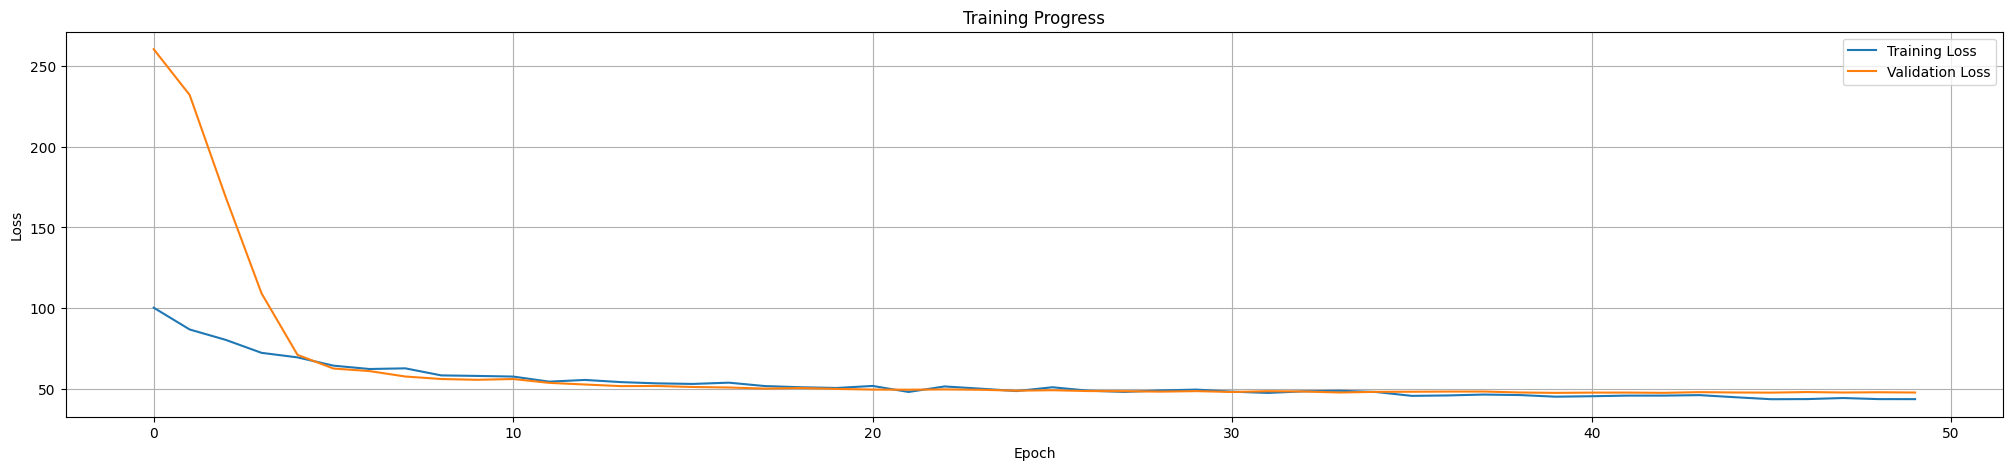

Final training loss:   43.8579
Final validation loss: 47.9480


In [4]:
# Function to convert [-1, 1] images to [0, 1] for display
def tanh_display(img):
    return (np.clip(img, -1, 1) + 1) / 2

# Reconstruct 10 test images
test_samples  = x_test[:10]
reconstructed = vae.predict(test_samples, verbose=0)

# Show originals vs reconstructions
fig = plt.figure(figsize=(25, 5))
gs = fig.add_gridspec(4, 10, height_ratios=[0.15, 1, 0.15, 1], hspace=0.05)

# Label rows
for label, row in [('Original', 0), ('Reconstructed', 2)]:
    ax = fig.add_subplot(gs[row, :])
    ax.text(0.5, 0.5, label, ha='center', va='center', fontsize=12, fontweight='bold')
    ax.axis('off')

# Image rows
for i in range(10):
    ax = fig.add_subplot(gs[1, i])
    ax.imshow(tanh_display(test_samples[i]))
    ax.axis('off')

    ax = fig.add_subplot(gs[3, i])
    ax.imshow(tanh_display(reconstructed[i]))
    ax.axis('off')

plt.suptitle('VAE Reconstructions', fontsize=16)
plt.tight_layout()
plt.show()

# Generate 10 new images
n_samples = 10
random_latent = np.random.normal(size=(n_samples, LATENT_DIM))
generated = decoder.predict(random_latent, verbose=0)

fig, axes = plt.subplots(1, 10, figsize=(20, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(tanh_display(generated[i]))
    ax.axis('off')

plt.suptitle('VAE Generations', fontsize=16)
plt.tight_layout()
plt.show()

# Training loss curve
plt.figure(figsize=(25, 5))
plt.plot(history.history['loss'],     label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Progress')
plt.legend()
plt.grid(True)
plt.show()

print(f"Final training loss:   {history.history['loss'][-1]:.4f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.4f}")